# 05_life_projection.ipynb

**Purpose:** Convert the static stress intelligence into tire life projections:
- compute effective life (km) given stress,
- remaining life percentage,
- categorize life health,
- export `tire_life_projection_v1.csv` and a short maintenance report.

**Inputs:** `data/enriched/tire_intelligence_v1.csv`  
**Outputs:** `data/enriched/tire_life_projection_v1.csv`, `data/enriched/life_projection_report_v1.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Config
CONFIG = {
    "MIN_EFFECTIVE_LIFE_FACTOR": 0.0,   # lower bound factor (0 => zero life allowed)
    "MAX_EFFECTIVE_LIFE_FACTOR": 1.0,   # upper bound factor (1 => no extension)
    "HEALTH_THRESH_GOOD": 0.70,         # >= 70% remaining considered Healthy
    "HEALTH_THRESH_WATCH": 0.40,        # 40-70% is Watch
    "MODEL_VERSION": "v0.1-life",
}

OUT_DIR = "data/enriched"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PATH = os.path.join(OUT_DIR, "tire_life_projection_v1.csv")
REPORT_PATH = os.path.join(OUT_DIR, "life_projection_report_v1.csv")

In [5]:
IN_PATH = "E:\\TPMS\\data\\enriched\\tire_intelligence_v1.csv"
if not os.path.exists(IN_PATH):
    raise FileNotFoundError(f"Required file not found: {IN_PATH}. Run previous notebooks first.")

df = pd.read_csv(IN_PATH)
print("Loaded:", IN_PATH)
display(df.head())

# Required columns check
required = ["vehicle_id", "tyre_life", "stress_score"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in intelligence CSV: {missing}")

# Ensure tyre_life numeric and > 0 where present
df["tyre_life"] = pd.to_numeric(df["tyre_life"], errors="coerce")
if df["tyre_life"].isna().all():
    raise ValueError("tyre_life column is missing or entirely non-numeric. Life projection needs base tyre_life.")

Loaded: E:\TPMS\data\enriched\tire_intelligence_v1.csv


,vehicle_id,vehicle_type,load_per_wheel,max_load_single_kg,load_utilization,load_margin_kg,driven_wheels,total_wheels,driven_ratio,initial_tread,...,adjusted_wear_rate,stress_score,stress_score_adj,risk_level,recommended_action,maintenance_priority,priority_rank,explanation,run_timestamp,model_version
0,MH47MD4509,Box Van,1075.000000,1450,0.741379,375.000000,2,4,0.500000,9.0,...,0.138462,0.693103,0.508196,Moderate,Schedule maintenance check,0.001843,1,"Moderate stress:load_utilization=0.74(>0.7), d...",2026-03-01T20:06:31.187025+00:00,v0.1-stress
1,RJ21LM7621,Semi-Trailer,2750.000000,3550,0.774648,800.000000,4,6,0.666667,18.5,...,0.112121,0.753052,0.427136,High,Immediate inspection required,0.000940,2,"High stress:load_utilization=0.77(>0.7), drive...",2026-03-01T20:06:31.187025+00:00,v0.1-stress
2,MH14JK7645,TRUCK,2175.000000,3525,0.617021,1350.000000,2,4,0.500000,21.5,...,0.179167,0.593617,0.437769,Moderate,Schedule maintenance check,0.000439,3,"Moderate stress:load_utilization=0.62(>0.4), d...",2026-03-01T20:06:31.187025+00:00,v0.1-stress
3,MH12XD7689,Pickup,233.333333,1120,0.208333,886.666667,2,6,0.333333,12.2,...,0.221818,0.233333,0.363333,Low,Normal monitoring,0.000263,4,"Low stress:load_utilization=0.21, driven_ratio...",2026-03-01T20:06:31.187025+00:00,v0.1-stress


In [6]:
# Effective life: conservative linear model
# effective_life = tyre_life * (1 - stress_score)
# clip to [MIN_EFFECTIVE_LIFE_FACTOR, MAX_EFFECTIVE_LIFE_FACTOR] * tyre_life

min_f = CONFIG["MIN_EFFECTIVE_LIFE_FACTOR"]
max_f = CONFIG["MAX_EFFECTIVE_LIFE_FACTOR"]

# Ensure stress_score in [0,1]
df["stress_score"] = pd.to_numeric(df["stress_score"], errors="coerce").fillna(0.0)
df["stress_score"] = df["stress_score"].clip(0.0, 1.0)

# Compute factors and life estimates
df["effective_factor"] = (1.0 - df["stress_score"]).clip(min_f, max_f)
df["effective_life_km"] = (df["tyre_life"] * df["effective_factor"]).round(2)

# Remaining life percent relative to manufacturer tyre_life
df["remaining_life_pct"] = (df["effective_life_km"] / df["tyre_life"]).fillna(0.0)
df["remaining_life_pct"] = (df["remaining_life_pct"] * 100).round(2)  # percent

# Life reduction percent (how much life lost vs rated)
df["life_reduction_pct"] = (df["stress_score"] * 100).round(2)

display(df[["vehicle_id","tyre_life","stress_score","effective_life_km","remaining_life_pct","life_reduction_pct"]])

,vehicle_id,tyre_life,stress_score,effective_life_km,remaining_life_pct,life_reduction_pct
0,MH47MD4509,65000,0.693103,19948.28,30.69,69.31
1,RJ21LM7621,165000,0.753052,40746.48,24.69,75.31
2,MH14JK7645,120000,0.593617,48765.96,40.64,59.36
3,MH12XD7689,55000,0.233333,42166.67,76.67,23.33


In [7]:
def life_health_label(pct, good=CONFIG["HEALTH_THRESH_GOOD"], watch=CONFIG["HEALTH_THRESH_WATCH"]):
    frac = pct / 100.0
    if frac >= good:
        return "Healthy"
    elif frac >= watch:
        return "Watch"
    else:
        return "Critical"

df["life_health"] = df["remaining_life_pct"].apply(life_health_label)
action_map = {
    "Healthy": "Normal monitoring",
    "Watch": "Schedule inspection within next service",
    "Critical": "Immediate inspection and consider replacement"
}
df["life_recommendation"] = df["life_health"].map(action_map)

display(df[["vehicle_id","remaining_life_pct","life_health","life_recommendation"]])

,vehicle_id,remaining_life_pct,life_health,life_recommendation
0,MH47MD4509,30.69,Critical,Immediate inspection and consider replacement
1,RJ21LM7621,24.69,Critical,Immediate inspection and consider replacement
2,MH14JK7645,40.64,Watch,Schedule inspection within next service
3,MH12XD7689,76.67,Healthy,Normal monitoring


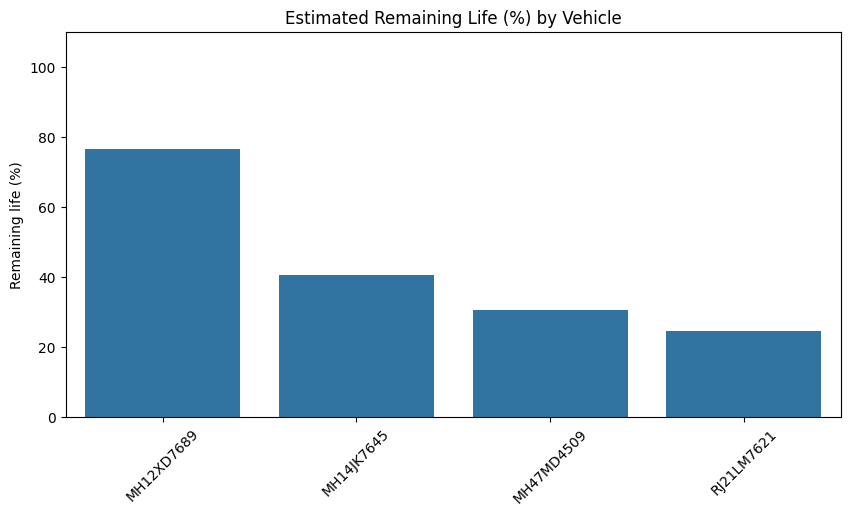

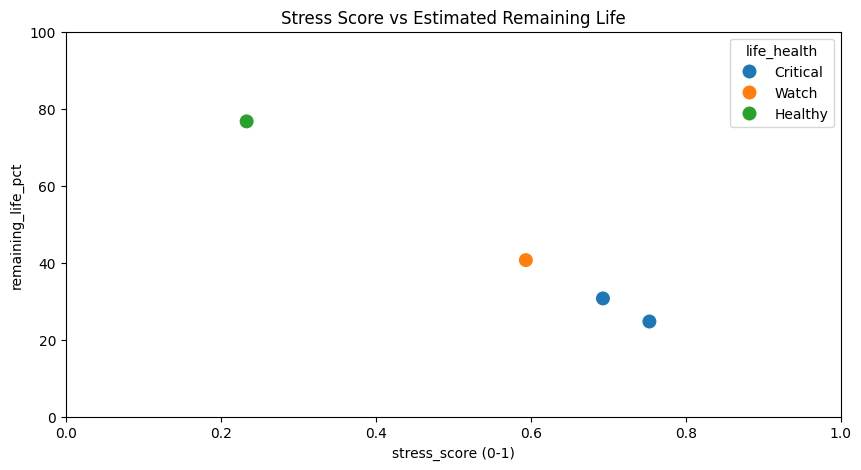

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(x="vehicle_id", y="remaining_life_pct", data=df.sort_values("remaining_life_pct", ascending=False))
plt.title("Estimated Remaining Life (%) by Vehicle")
plt.ylabel("Remaining life (%)")
plt.xlabel("")
plt.ylim(0, 110)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(x="stress_score", y="remaining_life_pct", hue="life_health", data=df, s=120)
plt.title("Stress Score vs Estimated Remaining Life")
plt.xlabel("stress_score (0-1)")
plt.ylabel("remaining_life_pct")
plt.xlim(0,1)
plt.ylim(0,100)
plt.show()

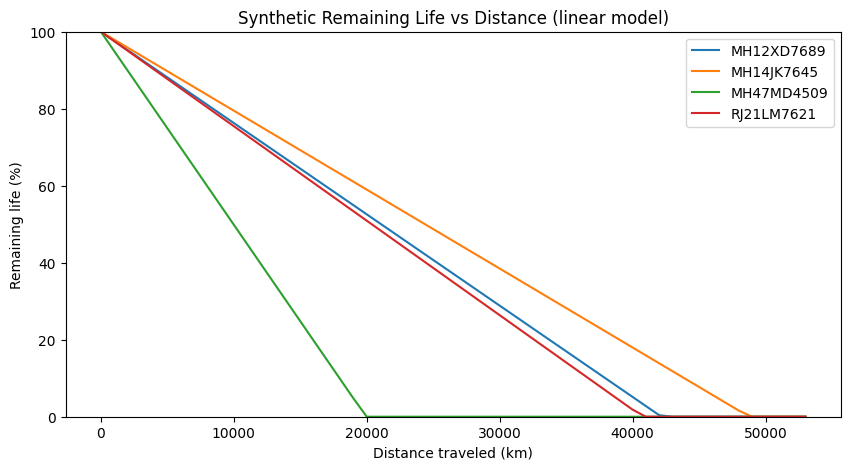

In [9]:
# Optional simulation: simulate how effective life decreases as a function of distance traveled
# Assumes linear wear; this is only a demo tool for visualization, not a physical model.

simulate = True  # set False to skip
if simulate:
    sim_km = np.arange(0, 1.1 * df["effective_life_km"].max(), step=1000)  # steps of 1,000 km up to 110% of max effective life
    sim_frames = []
    for _, row in df.iterrows():
        base = row["effective_life_km"]
        # remaining percent at distance d: max(0, 1 - d/base)
        rem_pct = np.maximum(0, 1 - (sim_km / (base + 1e-9))) * 100
        tmp = pd.DataFrame({
            "vehicle_id": row["vehicle_id"],
            "distance_km": sim_km,
            "remaining_pct_sim": rem_pct
        })
        sim_frames.append(tmp)
    sim_df = pd.concat(sim_frames, ignore_index=True)
    # plot for each vehicle
    plt.figure(figsize=(10,5))
    for vid, grp in sim_df.groupby("vehicle_id"):
        plt.plot(grp["distance_km"], grp["remaining_pct_sim"], label=str(vid))
    plt.xlabel("Distance traveled (km)")
    plt.ylabel("Remaining life (%)")
    plt.title("Synthetic Remaining Life vs Distance (linear model)")
    plt.legend()
    plt.ylim(0,100)
    plt.show()

In [10]:
# Save enriched life projection CSV
df["run_timestamp"] = pd.Timestamp.utcnow().isoformat()
df["model_version"] = CONFIG["MODEL_VERSION"]
cols_out = ["vehicle_id","tyre_life","stress_score","effective_life_km","remaining_life_pct","life_reduction_pct",
            "life_health","life_recommendation","run_timestamp","model_version"]
# ensure these columns exist
cols_out = [c for c in cols_out if c in df.columns]
df[cols_out].to_csv(OUT_PATH, index=False)
print("Saved life projection CSV:", OUT_PATH)

# Save a short report for ops (top critical first)
report = df.sort_values(["life_health","remaining_life_pct"], ascending=[True, True]).head(20)
report_cols = ["vehicle_id","remaining_life_pct","life_health","life_recommendation","stress_score","effective_life_km"]
report = report[[c for c in report_cols if c in report.columns]]
report.to_csv(REPORT_PATH, index=False)
print("Saved life projection report:", REPORT_PATH)
display(report)

Saved life projection CSV: data/enriched\tire_life_projection_v1.csv
Saved life projection report: data/enriched\life_projection_report_v1.csv


,vehicle_id,remaining_life_pct,life_health,life_recommendation,stress_score,effective_life_km
1,RJ21LM7621,24.69,Critical,Immediate inspection and consider replacement,0.753052,40746.48
0,MH47MD4509,30.69,Critical,Immediate inspection and consider replacement,0.693103,19948.28
3,MH12XD7689,76.67,Healthy,Normal monitoring,0.233333,42166.67
2,MH14JK7645,40.64,Watch,Schedule inspection within next service,0.593617,48765.96


In [11]:
# Validation asserts
assert df["effective_life_km"].notna().all(), "Some effective life values are NaN"
assert df["remaining_life_pct"].between(0, 200).all(), "Remaining life pct outside expected range (0-200)"

# Summary
print("Summary counts by life_health:")
display(df["life_health"].value_counts())

print("Average effective life (km):", df["effective_life_km"].mean())
print("Vehicle with lowest remaining life pct:", df.loc[df["remaining_life_pct"].idxmin(),"vehicle_id"])

Summary counts by life_health:


life_health
Critical    2
Watch       1
Healthy     1
Name: count, dtype: int64

Average effective life (km): 37906.8475
Vehicle with lowest remaining life pct: RJ21LM7621


## Recommendations & next steps

- Review vehicles marked **Critical** and confirm tyre_life base values are correct.
- If you obtain telemetry in future, replace linear model with time-based degradation modeling and physics RUL: simulate dP/dt and wear over distance.
- Consider an adjusted effective life model using `adjusted_wear_rate` if that column becomes available: e.g. `effective_life = tyre_life / (1 + gamma * adjusted_wear_rate)`.
- Integrate `tire_life_projection_v1.csv` into the dashboard or API for operations consumption.